In [35]:
import sys
sys.path.append('../')

import torch
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from flashtorch.utils import apply_transforms, load_image
from flashtorch.saliency import Backprop

from model_conv import SimpleCNNSmall_4Layer, SimpleP4CNNSmall
import torchvision.models as models
from rule_simulator import RuleSimulatorStats
from train_test import apply_rotation, apply_translation

In [60]:
import model_conv

list(filter(lambda x: "P4" in x, model_conv.__dict__.keys()))

['SimpleP4CNNSmall',
 'SimpleP4MCNNSmall',
 'SimpleP4CNNSmalL2Layer',
 'SimpleP4CNNTiny',
 'MultiScaleP4']

In [72]:
apply_random_rt = lambda x: apply_translation(*apply_rotation(*x))

res = {}

for name in filter(lambda x: "P4" in x, model_conv.__dict__.keys()):
    sum_ = 0
    
    res[name] = []
    
    for scale in [1, 10, 100, 1000]:
    
        for _ in range(10):
            arr = torch.randn(1, 1, 200, 200) * scale
            model = getattr(model_conv, name)()
            out = model(arr)
            arr_r, out_r = apply_random_rt((arr, out))
            
            sum_ += torch.sum(torch.abs(model(arr_r) - out_r))
            
        res[name].append((sum_ / 10).detach().item())        

Text(0.5, 0, 'Input Scale')

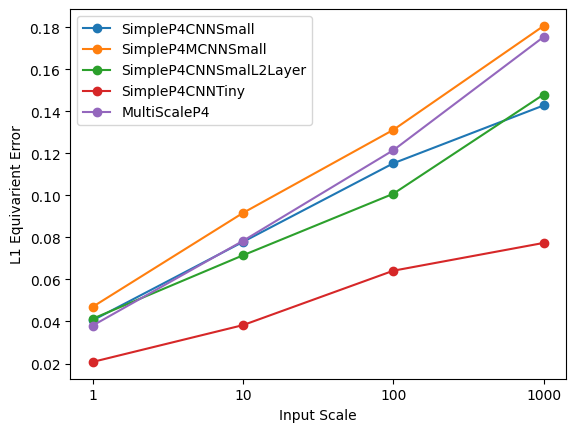

In [ ]:
import matplotlib.pyplot as plt 

for key, value in res.items():
    plt.plot(value, label=key, marker="o")
plt.legend()
plt.xticks([0, 1, 2, 3], [1, 10, 100, 1000])
plt.ylabel("L1 Equivarient Error")
plt.xlabel("Input Scale")

In [99]:
p = "/Users/heruijie/BIMSA/result/predictor_life_simple/2026-03-14_13-47-07_small_3_layer_seq_cnn__200-200-B36_S23/best_simple_life_SimpleCNNSmall_0.1.0.pth"


model = model_conv.SimpleCNNSmall()
model.load_state_dict(torch.load(p, map_location="cpu"))

import dataloader

dataset = dataloader.get_dataloader(
    "/Users/heruijie/BIMSA/predictor_life_simple/datasets/200-200-B36_S23",
    batch_size=64, 
    split="train",
)

r = 0

for _ in range(100):
    arr, _ = next(iter(dataset))
    out = model(arr)
    arr_r, out_r = apply_random_rt((arr, out))

    print(torch.sum(torch.abs(model(arr_r) - out_r)))

tensor(10558372., grad_fn=<SumBackward0>)
tensor(38.1432, grad_fn=<SumBackward0>)
tensor(11254836., grad_fn=<SumBackward0>)
tensor(10675508., grad_fn=<SumBackward0>)
tensor(10252584., grad_fn=<SumBackward0>)
tensor(10488441., grad_fn=<SumBackward0>)
tensor(10498216., grad_fn=<SumBackward0>)
tensor(42.8097, grad_fn=<SumBackward0>)
tensor(9978340., grad_fn=<SumBackward0>)
tensor(5734929., grad_fn=<SumBackward0>)
tensor(9989323., grad_fn=<SumBackward0>)
tensor(6214124., grad_fn=<SumBackward0>)
tensor(42.4476, grad_fn=<SumBackward0>)
tensor(37.7267, grad_fn=<SumBackward0>)
tensor(10181169., grad_fn=<SumBackward0>)
tensor(6066914.5000, grad_fn=<SumBackward0>)
tensor(10434254., grad_fn=<SumBackward0>)
tensor(10971370., grad_fn=<SumBackward0>)
tensor(11050822., grad_fn=<SumBackward0>)
tensor(5985237., grad_fn=<SumBackward0>)
tensor(39.1484, grad_fn=<SumBackward0>)
tensor(10426741., grad_fn=<SumBackward0>)
tensor(10756616., grad_fn=<SumBackward0>)
tensor(10245328., grad_fn=<SumBackward0>)
tens

KeyboardInterrupt: 

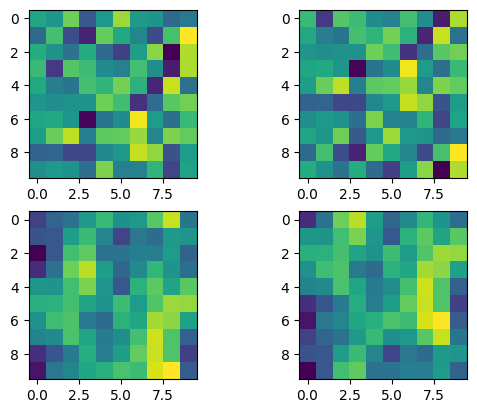

In [ ]:


plt.subplot(2, 2, 1)
plt.imshow(arr.detach().numpy()[0, 0])

plt.subplot(2, 2, 2)
plt.imshow((arr_r := apply_random_rt((arr, ))[0]).detach().numpy()[0, 0])

plt.subplot(2, 2, 3)
plt.imshow(out.detach().numpy()[0, 0])

plt.subplot(2, 2, 4)
plt.imshow(model(arr_r).detach().numpy()[0, 0])